# UMAP — Topic 1: Theory

## 1. What is UMAP?

**UMAP (Uniform Manifold Approximation and Projection)** is a dimensionality-reduction algorithm used to represent high-dimensional data in a lower-dimensional space.

For example:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

The main idea is:

> **Preserve the important relationships between nearby points while creating a useful low-dimensional representation.**

---

## 2. Intuition

Imagine points in high-dimensional space forming different shapes:

```text
● ● ● ●
 ● ● ●
  ● ●
```

The data may have a complicated structure that we cannot directly visualize.

UMAP tries to understand the **neighborhood structure** of the data and then create a low-dimensional representation with a similar structure.

So:

$$
\text{High-dimensional data}
\rightarrow
\text{Understand neighborhoods}
\rightarrow
\text{Low-dimensional representation}
$$

---

# 3. UMAP vs PCA

PCA focuses on directions with maximum variance:

$$
\boxed{
\text{PCA}
\rightarrow
\text{Maximum Variance}
}
$$

UMAP focuses heavily on the **neighborhood structure**:

$$
\boxed{
\text{UMAP}
\rightarrow
\text{Neighborhood Structure}
}
$$

UMAP can also capture **nonlinear structure**, unlike standard PCA.

---

# 4. UMAP vs t-SNE

UMAP and t-SNE are more similar to each other than either is to PCA.

| PCA                  | t-SNE                | UMAP                                     |
| -------------------- | -------------------- | ---------------------------------------- |
| Linear               | Nonlinear            | Nonlinear                                |
| Maximum variance     | Local similarities   | Neighborhood structure                   |
| Fast                 | Relatively expensive | Usually faster than t-SNE                |
| Useful for reduction | Mainly visualization | Visualization + dimensionality reduction |

A key idea is:

$$
\boxed{
\text{UMAP tries to preserve both local structure and some global structure}
}
$$

whereas t-SNE is especially focused on local structure.

---

# 5. What Does "Manifold" Mean?

This is important for understanding UMAP.

A **manifold** is a lower-dimensional structure that exists inside a higher-dimensional space.

A simple example is a curved surface.

Imagine a sheet of paper:

```text
2D sheet
────────────
```

Now bend it:

```text
      /
     /
────/
```

The sheet exists in 3D space, but its underlying structure is still essentially 2D.

So:

$$
\text{High-dimensional space}
\supset
\text{lower-dimensional structure}
$$

UMAP assumes that high-dimensional data often has this kind of underlying structure.

---

# 6. Why Is This Useful?

Suppose your data has:

$$
100\text{ features}
$$

but the actual meaningful structure may effectively depend on only a smaller number of underlying factors.

UMAP attempts to uncover that structure:

$$
100\text{ dimensions}
\rightarrow
\text{underlying structure}
\rightarrow
2\text{ dimensions}
$$

This can reveal groups and patterns that are difficult to see in the original space.

---

# 7. Core Idea of UMAP

UMAP does not simply calculate a normal distance matrix and directly plot it.

Instead, it builds a **neighborhood graph**.

Imagine:

```text
A ─── B
│     │
C ─── D ─── E
```

Each point is connected to nearby points.

These connections represent:

> **Which points are neighbors and how strongly they are connected.**

So the basic UMAP idea is:

$$
\text{Data}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
\rightarrow
\text{Low-dimensional Graph}
\rightarrow
\text{Optimization}
\rightarrow
\text{Embedding}
$$

---

# 8. What Is the Goal?

Suppose two points are strong neighbors in the original space.

UMAP wants them to remain close after dimensionality reduction.

If:

$$
A\leftrightarrow B
$$

has a strong connection in the original space, UMAP tries to maintain:

$$
A\leftrightarrow B
$$

in the low-dimensional space.

So:

$$
\boxed{
\text{Strong original connection}
\rightarrow
\text{Strong low-dimensional connection}
}
$$

---

# 9. Main UMAP Mental Model

Think of UMAP as:

> **Build a map of who is connected to whom in the high-dimensional space, then find a low-dimensional map that preserves those connections as well as possible.**

The overall flow is:

$$
\boxed{
\text{High-dimensional Data}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
\rightarrow
\text{Fuzzy Graph}
\rightarrow
\text{Low-dimensional Graph}
\rightarrow
\text{Optimization}
\rightarrow
\text{Final Embedding}
}
$$


# Topic 2: Nearest Neighbors

UMAP starts by finding the **nearest neighbors of every data point**.

## 1. What does "Nearest Neighbor" mean?

For a point \(A\), its nearest neighbors are the points that are **closest to \(A\)** according to some distance measure.

For example:

```text
A ●
   ● B
     ● C
                 ● D
```

Here, B is closer to A than C or D.

So:

$$
\text{Point}
\rightarrow
\text{Calculate distances}
\rightarrow
\text{Find closest points}
$$

---

## 2. Why Does UMAP Need Nearest Neighbors?

UMAP wants to understand the **local structure** of the data.

Instead of treating every point as equally important, it asks:

> "Which points are actually near this point?"

For every point, it creates a neighborhood.

For example, if:

$$
n_{\text{neighbors}}=3
$$

then for point A, UMAP identifies roughly its **3 closest neighboring points**.

This is similar to the idea of perplexity in t-SNE, but UMAP's `n_neighbors` is actually a **number of neighbors used to construct the neighborhood graph**.

---

## 3. Small Example

Suppose we have four points:

$$
A=(1,1)
$$

$$
B=(2,1)
$$

$$
C=(1,3)
$$

$$
D=(5,5)
$$

We calculate the Euclidean distance from A to each other point.

### A → B

$$
d(A,B)
=
\sqrt{(2-1)^2+(1-1)^2}
$$

$$
=
\sqrt{1}
$$

$$
=1
$$

### A → C

$$
d(A,C)
=
\sqrt{(1-1)^2+(3-1)^2}
$$

$$
=
\sqrt{4}
$$

$$
=2
$$

### A → D

$$
d(A,D)
=
\sqrt{(5-1)^2+(5-1)^2}
$$

$$
=
\sqrt{16+16}
$$

$$
=\sqrt{32}
\approx5.66
$$

Therefore:

$$
d(A,B)<d(A,C)<d(A,D)
$$

So the nearest neighbors of A are:

$$
\boxed{B,\ C,\ D}
$$

in that order.

If we choose:

$$
n_{\text{neighbors}}=2
$$

then UMAP keeps:

$$
\boxed{B,\ C}
$$

as A's nearest neighbors.

---

## 4. What Happens for Every Point?

UMAP doesn't do this only for A.

It does it for **every point**:

$$
A\rightarrow\text{nearest neighbors}
$$

$$
B\rightarrow\text{nearest neighbors}
$$

$$
C\rightarrow\text{nearest neighbors}
$$

$$
D\rightarrow\text{nearest neighbors}
$$

This gives us the information needed to construct the **neighborhood graph**.

So the flow is:

$$
\boxed{
\text{Data}
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
}
$$

# Topic 3: Distance Metrics

UMAP needs a way to decide **how close or far two points are**.

That is what a **distance metric** does.

## 1. What is a Distance Metric?

A distance metric gives a numerical value representing the distance between two points.

For example:

$$
d(A,B)=2
$$

means A and B are closer than two points with:

$$
d(A,C)=5
$$

So:

$$
\boxed{\text{Smaller distance} \rightarrow \text{more similar/closer}}
$$

---

## 2. Euclidean Distance

The most common distance is **Euclidean distance**.

For two points:

$$
A=(x_1,x_2)
$$

and:

$$
B=(y_1,y_2)
$$

the distance is:

$$
d(A,B)
=
\sqrt{
(x_1-y_1)^2+(x_2-y_2)^2
}
$$

### Example

Suppose:

$$
A=(1,2)
$$

and:

$$
B=(4,6)
$$

Then:

$$
d(A,B)
=
\sqrt{
(4-1)^2+(6-2)^2
}
$$

$$
=
\sqrt{
3^2+4^2
}
$$

$$
=
\sqrt{9+16}
$$

$$
=
\sqrt{25}
$$

$$
=5
$$

So the distance between A and B is:

$$
\boxed{5}
$$

---

## 3. Why Does UMAP Need This?

UMAP needs distance to find nearest neighbors.

The flow is:

$$
\text{Data}
\rightarrow
\text{Calculate Distances}
\rightarrow
\text{Find Nearest Neighbors}
$$

For example, if A has distances:

$$
d(A,B)=1
$$

$$
d(A,C)=3
$$

$$
d(A,D)=7
$$

then:

$$
B
\rightarrow
\text{nearest}
$$

$$
C
\rightarrow
\text{second nearest}
$$

$$
D
\rightarrow
\text{farther away}
$$

---

## 4. UMAP Can Use Different Distance Metrics

UMAP isn't restricted to Euclidean distance.

Depending on the data, metrics such as:

* Euclidean
* Manhattan
* Cosine
* Correlation

can be used.

For example, **cosine distance** can be useful when the **direction/pattern of vectors** matters more than their magnitude.

The important idea is:

$$
\boxed{
\text{Distance metric determines what "similar" means}
}
$$

---

## 5. Connection to Nearest Neighbors

Remember our previous topic:

$$
\text{Nearest Neighbors}
$$

To find a nearest neighbor, UMAP first needs to know:

> **"What does close mean?"**

The distance metric answers that.

Therefore:

$$
\boxed{
\text{Distance Metric}
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
}
$$

And those neighbors will then be used to construct UMAP's **neighborhood graph**.


# Topic 4: Neighborhood Graph

Now UMAP has found the **nearest neighbors** of every point.

The next step is to represent those neighbor relationships as a **graph**.

## 1. What is a Neighborhood Graph?

A graph contains:

* **Nodes** → data points
* **Edges** → connections between nearby points

For example:

```text
A ─── B
│     │
C ─── D ─── E
```

Here:

* A, B, C, D, E are data points.
* The lines represent neighborhood relationships.

So:

$$
\boxed{
\text{Data Points}
\rightarrow
\text{Nodes}
}
$$

$$
\boxed{
\text{Nearest-Neighbor Relationships}
\rightarrow
\text{Edges}
}
$$

---

## 2. Why Does UMAP Build This Graph?

Because UMAP wants to capture the **structure of the data**.

Instead of remembering every distance between every pair, it focuses on:

> **Which points are connected to nearby points?**

For example:

$$
A\rightarrow B
$$

means B is a neighbor of A.

If many points are connected:

```text
A ─ B ─ C
│   │
D ─ E
```

this represents a local region of the original data.

---

## 3. Small Example

Suppose:

$$
n_{\text{neighbors}}=2
$$

and we have four points.

After calculating distances, suppose UMAP finds:

$$
A\rightarrow B,C
$$

$$
B\rightarrow A,C
$$

$$
C\rightarrow A,B
$$

$$
D\rightarrow C,B
$$

We can represent these relationships as:

```text
      A
     / \
    B---C
     \ /
      D
```

The exact graph can be more complex for a real dataset.

---

## 4. Are All Connections Equal?

Initially, the important information is **which points are neighbors**.

But UMAP goes further.

It wants to represent **how strongly connected** two neighboring points are.

For example:

$$
A\longleftrightarrow B
$$

might have a stronger connection than:

$$
A\longleftrightarrow C
$$

because B is much closer to A.

This leads to the idea of a **weighted/fuzzy neighborhood graph**.

That is the next important step.

---

## 5. Complete Flow So Far

We now have:

$$
\text{Data}
\rightarrow
\text{Distance Metric}
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\boxed{\text{Neighborhood Graph}}
$$

The neighborhood graph is essentially UMAP's way of saying:

> **"These are the local relationships that exist in my original high-dimensional data."**


# Topic 5: Local Connectivity

UMAP has found the nearest neighbors. Now it needs to determine **how strongly each point is connected to its neighbors**.

## 1. Why is this needed?

Consider point \(A\).

Suppose its nearest neighbors are:

* \(B\) — very close
* \(C\) — somewhat far
* \(D\) — even farther

Simply saying:

$$
A\rightarrow B,C,D
$$

doesn't tell us **how close** they are.

UMAP therefore needs to account for the **local distance scale around each point**.

---

## 2. What is Local Connectivity?

UMAP determines a local distance threshold for each point, called:

$$
\rho_i
$$

It is essentially based on the distance from point \(i\) to its **nearest neighbor**.

For example, suppose for point \(A\):

$$
d(A,B)=2
$$

and B is A's nearest neighbor.

Then approximately:

$$
\rho_A=2
$$

This tells UMAP:

> "For A, distances up to around 2 are within its immediate local connectivity."

---

## 3. Why Does Every Point Get Its Own \(\rho_i\)?

Because data may have **different densities**.

Imagine:

```text id="r7c5zw"
Dense region:

● ● ● ●
 ● ● ●


Sparse region:

●          ●
      ●
```

The distances between neighbors in the dense region are small.

The distances in the sparse region are larger.

If UMAP used one fixed distance threshold for everything, it would not handle these regions equally well.

Therefore:

$$
\boxed{
\text{Each point gets its own local scale}
}
$$

---

## 4. Small Example

Suppose we have:

$$
A=(1,1)
$$

and its nearest neighbors have distances:

$$
d(A,B)=1
$$

$$
d(A,C)=3
$$

$$
d(A,D)=5
$$

Since B is the nearest neighbor:

$$
\rho_A=1
$$

Now consider another point \(D\) in a sparse region.

Suppose its nearest-neighbor distance is:

$$
\rho_D=4
$$

So:

$$
\rho_A=1
$$

but:

$$
\rho_D=4
$$

This makes sense because A is in a dense region while D is in a sparse region.

---

## 5. What Does This Do?

UMAP uses this local scale when converting distances into **connection strengths**.

The basic idea is:

$$
\boxed{
\text{Distance}
-
\text{Local distance scale}
\rightarrow
\text{Connection strength}
}
$$

A point very close relative to its local neighborhood gets a strong connection.

A point farther away gets a weaker connection.

---

## 6. Connection to the Next Step

So far:

$$
\text{Data}
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
\rightarrow
\boxed{\text{Local Connectivity}}
$$


Yes, **almost**.

For each point \(i\), UMAP looks at its neighbors and takes the **distance to its nearest neighbor** as the local connectivity value:

$$
\rho_i=\min_{j\in N(i)} d(x_i,x_j)
$$

So for point A, if its neighbor distances are:

$$
1,\ 3,\ 5,\ 7
$$

then:

$$
\rho_A=1
$$

### Important

It's calculated **separately for every point**.

For example:

$$
\rho_A=1
$$

$$
\rho_B=2
$$

$$
\rho_C=0.5
$$

because each point may have a different nearest-neighbor distance.

So your understanding is:

> **For each point, find the smallest distance among its neighbors. That becomes its local connectivity distance \(\rho_i\).**


# Topic 6: Fuzzy Graph

Now UMAP has:

$$
\text{Nearest Neighbors}
\rightarrow
\text{Local Connectivity}
$$

But we don't just want to say:

> "A and B are connected."

We want to say:

> **"How strongly are A and B connected?"**

That's where the **fuzzy graph** comes in.

---

## 1. Hard Graph vs Fuzzy Graph

A normal graph might say:

$$
A\longleftrightarrow B
$$

meaning they are connected.

But a fuzzy graph gives the connection a **strength** between 0 and 1.

For example:

$$
A\longleftrightarrow B\quad 0.95
$$

means very strong connection.

While:

$$
A\longleftrightarrow C\quad 0.20
$$

means weak connection.

So:

$$
\boxed{
\text{Fuzzy graph}=\text{connections + connection strengths}
}
$$

---

# 2. How Does UMAP Calculate the Strength?

UMAP uses the point's local distance scale.

A simplified form is:

$$
w_{ij}
=
\exp
\left(
-\frac{d(x_i,x_j)-\rho_i}{\sigma_i}
\right)
$$

when:

$$
d(x_i,x_j)>\rho_i
$$

Here:

* \(d(x_i,x_j)\) = distance between points
* \(\rho_i\) = local connectivity distance
* \(\sigma_i\) = local scale parameter
* \(w_{ij}\) = connection strength

The exact UMAP implementation has additional details, but this is the important intuition.

---

## 3. Why Subtract \(\rho_i\)?

Remember:

$$
\rho_i
=
\text{distance to the nearest neighbor}
$$

Suppose:

$$
\rho_A=2
$$

and:

$$
d(A,B)=2
$$

Then B is right at A's local connectivity distance.

UMAP treats this as a **very strong/local connection**.

If instead:

$$
d(A,C)=5
$$

then C is farther beyond A's local scale, so its connection is weaker.

Therefore:

$$
\boxed{
\text{Closer relative to local scale}
\rightarrow
\text{Stronger connection}
}
$$

---

# 4. Small Example

Suppose for point A:

$$
\rho_A=2
$$

and:

$$
\sigma_A=1
$$

For B:

$$
d(A,B)=2
$$

Since B is at the local connectivity distance, its connection is treated as very strong.

For C:

$$
d(A,C)=3
$$

Then:

$$
w_{AC}
=
\exp
\left(
-\frac{3-2}{1}
\right)
$$

$$
=
e^{-1}
$$

$$
\approx0.368
$$

For D:

$$
d(A,D)=4
$$

Then:

$$
w_{AD}
=
\exp
\left(
-\frac{4-2}{1}
\right)
$$

$$
=
e^{-2}
$$

$$
\approx0.135
$$

So approximately:

$$
A\rightarrow B:\text{ very strong}
$$

$$
A\rightarrow C:0.368
$$

$$
A\rightarrow D:0.135
$$

The farther a point is relative to A's local scale, the weaker the connection.

---

# 5. Why "Fuzzy"?

Because the relationship isn't simply:

$$
\text{Connected}=1
$$

or:

$$
\text{Not connected}=0
$$

Instead:

$$
0\leq w_{ij}\leq1
$$

For example:

$$
0.95,\quad0.7,\quad0.3,\quad0.05
$$

represent different levels of connection.

This allows UMAP to represent the neighborhood structure more smoothly.

---

# 6. Connection to the Whole Process

Now our flow is:

$$
\text{Data}
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Local Connectivity}
\rightarrow
\boxed{\text{Fuzzy Graph}}
$$

The fuzzy graph now contains:

> **Which points are neighbors and how strongly they are connected.**

UMAP will use this graph to construct the low-dimensional representation.


# Topic 7: UMAP Workflow

Now let's put everything we've learned together.

## Complete Flow

$$
\text{High-dimensional Data}
\rightarrow
\text{Distance Calculation}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
$$

$$
\rightarrow
\text{Local Connectivity}
\rightarrow
\text{Fuzzy Graph}
\rightarrow
\text{Initial Low-dimensional Positions}
$$

$$
\rightarrow
\text{Low-dimensional Graph}
\rightarrow
\text{Optimization}
\rightarrow
\text{Final Embedding}
$$

---

## Step 1: Input Data

Suppose:

$$
X=
\begin{bmatrix}
1&1\\
2&1\\
1&2\\
8&8
\end{bmatrix}
$$

We have 4 points.

---

## Step 2: Calculate Distances

UMAP uses a distance metric, such as Euclidean distance.

For example:

$$
d(A,B)=1
$$

while:

$$
d(A,D)\approx9.90
$$

So A is much closer to B than D.

---

## Step 3: Find Nearest Neighbors

Suppose:

$$
n_{\text{neighbors}}=2
$$

UMAP finds the closest 2 points for each point.

This gives us local neighborhoods.

$$
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
$$

---

## Step 4: Build Neighborhood Graph

The points become nodes and their neighbor relationships become edges.

Conceptually:

```text id="3z7x6t"
A ─ B
│
C

D
```

Now UMAP knows **who is connected to whom**.

---

## Step 5: Calculate Local Connectivity

For each point, find its nearest-neighbor distance:

$$
\rho_i=\min_{j\in N(i)}d(x_i,x_j)
$$

This gives each point its own local distance scale.

---

## Step 6: Create Fuzzy Graph

Now instead of simply saying:

$$
A\leftrightarrow B
$$

UMAP assigns a connection strength:

$$
A\leftrightarrow B\quad 0.9
$$

or:

$$
A\leftrightarrow C\quad0.3
$$

So the graph now represents:

$$
\boxed{
\text{Who is connected + how strongly}
}
$$

This is the high-dimensional representation UMAP wants to preserve.

---

# Step 7: Create Initial Low-dimensional Positions

UMAP now needs to place the points in 2D.

It starts with initial positions:

$$
Y=
\begin{bmatrix}
y_{11}&y_{12}\\
y_{21}&y_{22}\\
y_{31}&y_{32}\\
y_{41}&y_{42}
\end{bmatrix}
$$

These are starting positions.

They are then optimized.

---

# Step 8: Build Low-dimensional Relationships

UMAP checks how strongly the points are connected in their current low-dimensional positions.

If two points that should be strongly connected are far apart, that's bad.

If they are close, that's good.

---

# Step 9: Optimization

UMAP moves the points to make the low-dimensional relationships resemble the original fuzzy graph.

Conceptually:

$$
\text{Strong connection}
\rightarrow
\text{Pull points together}
$$

$$
\text{Weak/no connection}
\rightarrow
\text{Allow points to separate}
$$

This happens repeatedly.

$$
Y
\rightarrow
\text{Calculate low-dimensional relationships}
\rightarrow
\text{Optimize}
\rightarrow
Y_{\text{new}}
\rightarrow
\cdots
$$

---

# Step 10: Final Embedding

After optimization:

$$
Y_{\text{final}}
=
\begin{bmatrix}
y_{11}&y_{12}\\
y_{21}&y_{22}\\
y_{31}&y_{32}\\
y_{41}&y_{42}
\end{bmatrix}
$$

These are the final 2D coordinates.

Then:

$$
Y_{\text{final}}
\rightarrow
\text{Plot}
$$

---

## Entire UMAP Flow

$$
\boxed{
X
\rightarrow
\text{Distances}
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Neighborhood Graph}
\rightarrow
\text{Local Connectivity}
\rightarrow
\text{Fuzzy Graph}
}
$$

$$
\boxed{
\rightarrow
\text{Initial }Y
\rightarrow
\text{Low-dimensional Relationships}
\rightarrow
\text{Optimization}
\rightarrow
Y_{\text{final}}
\rightarrow
\text{Plot}
}
$$

The biggest difference from t-SNE is that **UMAP first builds a neighborhood/fuzzy graph and then tries to preserve that graph in the low-dimensional space**.


# Topic 8: Graph Optimization

After creating the fuzzy graph, UMAP has a representation of the **relationships in the original high-dimensional space**.

Now it needs to find 2D positions that preserve those relationships as much as possible.

## 1. What is being optimized?

Suppose two points have a strong connection:

$$
w_{ij}=0.9
$$

UMAP wants them to be **close** in the 2D space.

If two points have a weak connection:

$$
w_{ij}=0.1
$$

UMAP does not need to keep them close.

So the goal is:

$$
\boxed{
\text{Preserve strong connections}
}
$$

while allowing weakly connected points to separate.

---

## 2. Start With Random/Initial Positions

UMAP starts with initial low-dimensional coordinates:

$$
Y=
\begin{bmatrix}
y_{11}&y_{12}\\
y_{21}&y_{22}\\
y_{31}&y_{32}
\end{bmatrix}
$$

These are starting positions, not the final result.

---

## 3. Compare Current Positions With the Fuzzy Graph

Suppose A and B have:

$$
w_{AB}=0.9
$$

but in the current 2D arrangement they are far apart.

UMAP says:

> They should be closer.

So the optimization creates an **attractive force** that pulls them together.

On the other hand, if two points have little or no connection and are unnecessarily close, the optimization can push them apart.

Conceptually:

$$
\boxed{
\text{Strong connection}
\rightarrow
\text{Attraction}
}
$$

$$
\boxed{
\text{Weak connection}
\rightarrow
\text{Repulsion}
}
$$

---

## 4. Repeatedly Move Points

UMAP updates the coordinates:

$$
Y_{\text{old}}
\rightarrow
Y_{\text{new}}
$$

Then it evaluates the new arrangement and updates again.

So:

$$
Y_0
\rightarrow
Y_1
\rightarrow
Y_2
\rightarrow
Y_3
\rightarrow
\cdots
\rightarrow
Y_{\text{final}}
$$

The optimization tries to make the final 2D arrangement represent the fuzzy graph well.

---

## 5. Simple Example

Suppose the original fuzzy graph says:

$$
w_{AB}=0.95
$$

meaning A and B are strongly connected.

But initially:

```text id="2nybq8"
A ●                         ● B
```

They are far apart.

Optimization moves them:

```text id="m8s5jo"
A ●       ● B
```

then:

```text id="k8d7d5"
A ● ● B
```

because preserving their strong connection requires them to be close.

At the same time, points with weak connections can remain farther apart.

---

## 6. The Important Difference From t-SNE

t-SNE optimizes:

$$
KL(P\parallel Q)
$$

UMAP instead starts from its **fuzzy neighborhood graph** and optimizes a low-dimensional representation so that its relationships match that graph.

So remember:

$$
\boxed{
\text{t-SNE}
\rightarrow
\text{Probability distributions }P,Q
\rightarrow
KL
}
$$

$$
\boxed{
\text{UMAP}
\rightarrow
\text{Fuzzy graph}
\rightarrow
\text{Graph-based optimization}
}
$$

The basic idea is the same at a high level:

$$
\text{Original relationships}
\rightarrow
\text{Low-dimensional positions}
\rightarrow
\text{Optimization}
$$

but the **way those relationships are represented and optimized is different**.


# Topic 9: `n_neighbors` and `min_dist`

These are two of the most important UMAP parameters, but they control **different things**.

---

## 1. `n_neighbors`

`n_neighbors` controls **how many nearby points UMAP considers when building the neighborhood structure**.

For example:

```python
n_neighbors=5
```

means UMAP uses the **5 nearest neighbors** of each point when constructing its local neighborhood.

$$
\boxed{
n_{\text{neighbors}}
\rightarrow
\text{Neighborhood size}
}
$$

### Small `n_neighbors`

```python
n_neighbors=5
```

UMAP focuses more on **local structure**.

$$
\text{Small }n_{\text{neighbors}}
\rightarrow
\text{More local detail}
$$

### Large `n_neighbors`

```python
n_neighbors=50
```

UMAP considers a broader neighborhood.

$$
\text{Large }n_{\text{neighbors}}
\rightarrow
\text{More global/broad structure}
$$

### Easy comparison with t-SNE

You can roughly think:

$$
\boxed{
\text{UMAP }n_{\text{neighbors}}
\approx
\text{t-SNE perplexity}
}
$$

because both control the **scale of the neighborhood**.

But they are not mathematically identical.

---

# 2. `min_dist`

`min_dist` controls **how close points are allowed to be in the low-dimensional embedding**.

For example:

```python
min_dist=0.1
```

allows points to be packed fairly closely.

---

## Small `min_dist`

Suppose:

```python
min_dist=0.01
```

Points can be placed very close together.

Result:

$$
\text{Small min\_dist}
\rightarrow
\text{Tighter, denser clusters}
$$

---

## Large `min_dist`

Suppose:

```python
min_dist=0.5
```

UMAP encourages points to maintain more separation.

Result:

$$
\text{Large min\_dist}
\rightarrow
\text{More spread-out embedding}
$$

---

# 3. Very Important Difference

Don't confuse them.

### `n_neighbors`

Controls:

> **How much of the original data's neighborhood UMAP looks at.**

$$
\boxed{
n_{\text{neighbors}}
\rightarrow
\text{Original-space neighborhood scale}
}
$$

### `min_dist`

Controls:

> **How tightly points can be packed in the low-dimensional representation.**

$$
\boxed{
\text{min\_dist}
\rightarrow
\text{Low-dimensional point spacing}
}
$$

---

## 4. Simple Example

Suppose we have:

```python
umap = UMAP(
    n_neighbors=10,
    min_dist=0.1
)
```

This means approximately:

> **Look at 10 nearest neighbors to understand the structure, and allow points to form relatively tight groups in the final embedding.**

So remember:

$$
\boxed{
n_{\text{neighbors}}
=
\text{"How much neighborhood?"}
}
$$

$$
\boxed{
\text{min\_dist}
=
\text{"How tightly packed in the embedding?"}
}
$$


# Topic 10: UMAP Implementation

Now we implement UMAP using Scikit-Learn's compatible UMAP library.

## 1. Import

```python
from umap import UMAP
```

---

## 2. Create the UMAP Model

```python
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
```

### `n_components`

Number of dimensions in the final output.

```python
n_components=2
```

means:

$$
\text{High-dimensional data}
\rightarrow
2\text{ dimensions}
$$

---

### `n_neighbors`

Controls the neighborhood size used to construct the graph.

```python
n_neighbors=15
```

means UMAP considers **15 nearest neighbors** for each point when building its neighborhood structure.

$$
\boxed{
n_{\text{neighbors}}
\rightarrow
\text{How much neighborhood structure to consider}
}
$$

---

### `min_dist`

Controls how tightly points can be packed in the final embedding.

```python
min_dist=0.1
```

Smaller value:

$$
\rightarrow
\text{tighter clusters}
$$

Larger value:

$$
\rightarrow
\text{more spread-out points}
$$

---

### `random_state`

```python
random_state=42
```

UMAP involves randomness, so this makes the result reproducible.

---

# 3. Fit and Transform

```python
X_umap = umap_model.fit_transform(X)
```

This performs the dimensionality reduction.

The flow is:

$$
X
\rightarrow
\text{UMAP}
\rightarrow
X_{\text{UMAP}}
$$

If the original data has 10 features:

$$
X\in\mathbb{R}^{n\times10}
$$

and:

```python
n_components=2
```

then:

$$
X_{\text{UMAP}}\in\mathbb{R}^{n\times2}
$$

---

# 4. Complete Basic Code

```python
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from umap import UMAP

# Load data
iris = load_iris()

X = iris.data
y = iris.target

# Create UMAP model
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

# Perform dimensionality reduction
X_umap = umap_model.fit_transform(X)

# Plot
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1]
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")

plt.show()
```

The practical flow is:

$$
X
\rightarrow
\text{Nearest Neighbors}
\rightarrow
\text{Fuzzy Graph}
\rightarrow
\text{Optimization}
\rightarrow
X_{\text{UMAP}}
\rightarrow
\text{Plot}
$$


C:\Users\Rupali Waghmare\miniconda3\envs\AI_ML\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


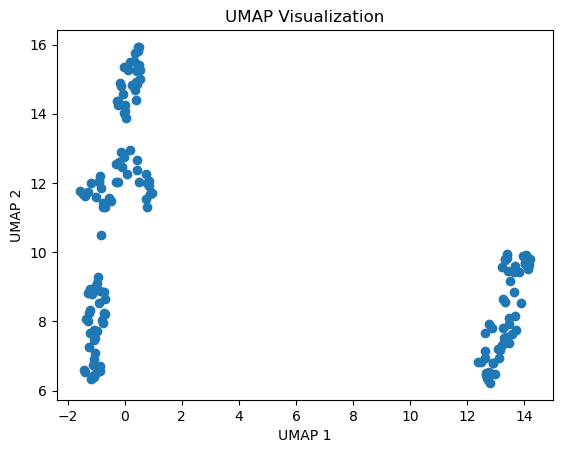

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from umap import UMAP

# Load data
iris = load_iris()

X = iris.data
y = iris.target

# Create UMAP model
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

# Perform dimensionality reduction
X_umap = umap_model.fit_transform(X)

# Plot
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1]
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")

plt.show()

# Topic 10: Visualization

After UMAP produces the reduced data:

$$
X
\rightarrow
X_{\text{UMAP}}
$$

where:

$$
X_{\text{UMAP}}=
\begin{bmatrix}
u_{11}&u_{12}\\
u_{21}&u_{22}\\
u_{31}&u_{32}
\end{bmatrix}
$$

we plot the two UMAP dimensions.

## Basic Plot

```python
import matplotlib.pyplot as plt

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1]
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")

plt.show()
```

Here:

```python
X_umap[:, 0]
```

means **first UMAP dimension**.

```python
X_umap[:, 1]
```

means **second UMAP dimension**.

So:

$$
\text{UMAP 1}\rightarrow x\text{-axis}
$$

$$
\text{UMAP 2}\rightarrow y\text{-axis}
$$

---

## Plotting Classes Separately

If we have class labels `y`:

```python
plt.figure()

plt.scatter(
    X_umap[y == 0, 0],
    X_umap[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_umap[y == 1, 0],
    X_umap[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_umap[y == 2, 0],
    X_umap[y == 2, 1],
    label="Class 2"
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")
plt.legend()

plt.show()
```

For:

```python
X_umap[y == 0, 0]
```

we are saying:

> Take points belonging to **Class 0**, and take their **first UMAP coordinate**.

For:

```python
X_umap[y == 0, 1]
```

we take their **second UMAP coordinate**.

---

## What Do We Look For?

### Points close together

$$
\boxed{
\text{Nearby points}
\rightarrow
\text{Similar local structure}
}
$$

### Separated groups

$$
\boxed{
\text{Separated groups}
\rightarrow
\text{Potentially different structures}
}
$$

But don't interpret:

> "UMAP 1 = some original feature"

UMAP 1 and UMAP 2 are **new dimensions created by UMAP**.

Also, don't interpret the exact distance between two clusters as a precise measure of how different they are.

The main purpose of this plot is to **see the structure and neighborhoods of the original high-dimensional data**.


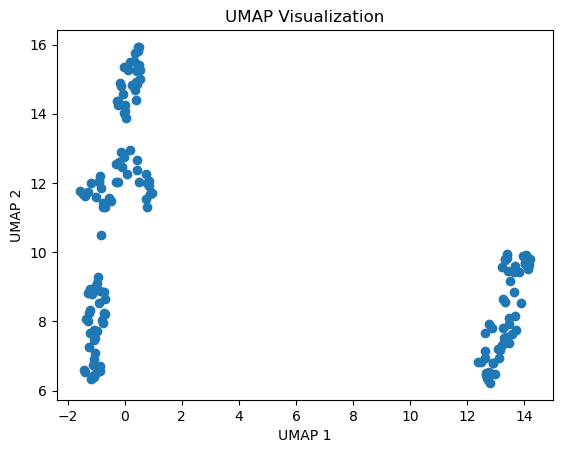

In [9]:
import matplotlib.pyplot as plt

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1]
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")

plt.show()

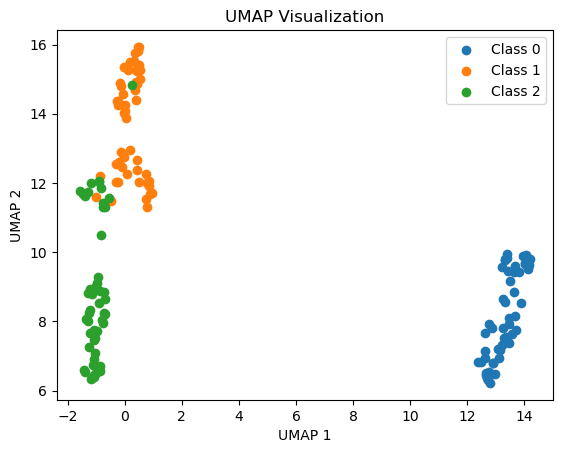

In [10]:
plt.figure()

plt.scatter(
    X_umap[y == 0, 0],
    X_umap[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_umap[y == 1, 0],
    X_umap[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_umap[y == 2, 0],
    X_umap[y == 2, 1],
    label="Class 2"
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")
plt.legend()

plt.show()

UMAP is **mostly used to visualize high-dimensional data** by reducing many features into 2D or 3D.

$$
\boxed{
\text{Many Features}
\rightarrow
\text{UMAP}
\rightarrow
2D/3D
\rightarrow
\text{Visualization}
}
$$

For example:

$$
100\text{ features}
\rightarrow
2\text{ UMAP dimensions}
\rightarrow
\text{plot}
$$

Then you can visually see:

* clusters
* groups
* similar points
* local patterns
* overall structure

So the simple purpose to remember is:

> **UMAP = reduce many dimensions mainly so we can visualize and understand the data's structure.**


# Topic 12: Advantages / Limitations

## Advantages

### 1. Good for Visualization

UMAP can reduce high-dimensional data:

$$
100\text{ features}
\rightarrow
2\text{ dimensions}
$$

This makes complex data easier to visualize.

### 2. Preserves Local Structure

It is good at keeping nearby points together:

$$
\text{Similar neighbors}
\rightarrow
\text{Remain close}
$$

### 3. Retains More Global Structure

Compared with t-SNE, UMAP generally does a better job of preserving broader relationships between different regions of the data.

### 4. Usually Faster Than t-SNE

For many datasets, UMAP can produce embeddings more efficiently than t-SNE.

### 5. Useful Beyond Visualization

UMAP can also be used as a dimensionality-reduction step before another ML task, although whether this is appropriate depends on the task and how much information is retained.

---

# Limitations

### 1. Parameter Sensitive

Results can change when you change:

$$
n_{\text{neighbors}}
$$

or:

$$
\text{min\_dist}
$$

### 2. Interpretation Is Not Always Straightforward

UMAP dimensions do not correspond directly to original features.

$$
\text{UMAP 1}\neq\text{Original Feature 1}
$$

### 3. Visualization Can Be Misleading

A visible cluster in a UMAP plot does not automatically prove that a real cluster exists.

### 4. Global Distances Are Not Exact

You should not treat the exact distance between two points or clusters in the embedding as a precise measurement of their original-space distance.

### 5. Randomness

Different random initializations can produce different-looking layouts.

---

## Main Mental Model

$$
\boxed{
\text{UMAP}
=
\text{Fast nonlinear dimensionality reduction}
+
\text{strong local structure preservation}
}
$$

It is especially useful when you want to **reduce many features into 2D/3D and visually understand the structure of the data**.
